In [49]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [50]:
import yfinance as yf
import datetime as dt


stock = "AAPL"
start = dt.datetime(2000,1,1)
end = dt.datetime(2026,5,20)

df = yf.download(stock,start,end).reset_index()


[*********************100%***********************]  1 of 1 completed


In [51]:
# # df = df.rename(columns={'Unnamed: 0': 'Date'})
# df.columns.values[-1] = 'Date'
# df.columns = df.columns.get_level_values(0)
df = df.rename(columns={'index': 'Date'})


In [52]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2000-01-03,0.837724,0.841934,0.761015,0.784870,535796800
1,2000-01-04,0.767096,0.827901,0.757273,0.810128,512377600
2,2000-01-05,0.778321,0.827434,0.770837,0.776450,778321600
3,2000-01-06,0.710966,0.800773,0.710966,0.794225,767972800
4,2000-01-07,0.744644,0.755870,0.714709,0.722192,460734400


In [53]:
df.columns.tolist()

[('Date', ''),
 ('Close', 'AAPL'),
 ('High', 'AAPL'),
 ('Low', 'AAPL'),
 ('Open', 'AAPL'),
 ('Volume', 'AAPL')]

In [54]:
df.to_csv("powergrid.csv")
dft = pd.read_csv("powergrid.csv")

In [55]:
dft.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,AAPL,AAPL,AAPL,AAPL,AAPL
1,0,2000-01-03,0.8377244472503662,0.8419338893785913,0.7610147885412782,0.7848697594321928,535796800
2,1,2000-01-04,0.767095685005188,0.8279014641623247,0.7572729232187219,0.8101275970742782,512377600
3,2,2000-01-05,0.778320848941803,0.8274338661548442,0.7708374692463978,0.7764499915279163,778321600
4,3,2000-01-06,0.7109662294387817,0.8007726803739019,0.7109662294387817,0.7942247044568762,767972800


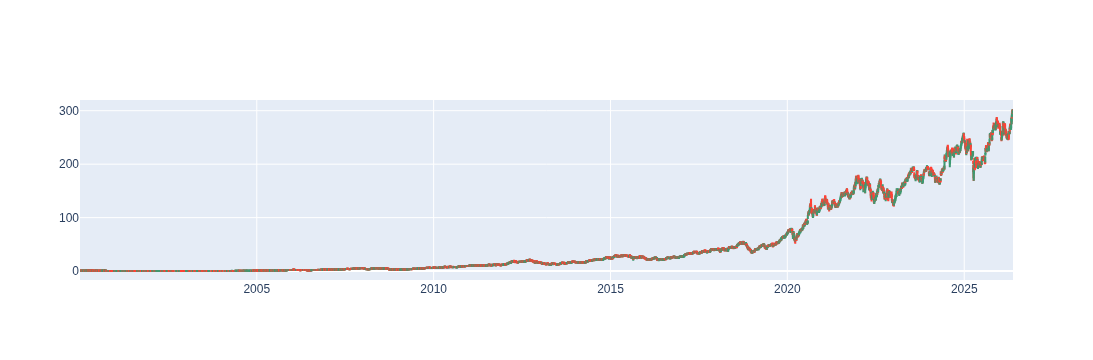

In [56]:
# CandleSticks
import plotly.graph_objects as go 

fig = go.Figure(data=[go.Candlestick(
    x=dft['Date'],
    open=dft['Open'],
    high=dft['High'],
    low=dft['Low'],
    close=dft['Close']
)])

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


In [57]:
dft.drop('Date', axis = 1)

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,0,0.8377244472503662,0.8419338893785913,0.7610147885412782,0.7848697594321928,535796800
2,1,0.767095685005188,0.8279014641623247,0.7572729232187219,0.8101275970742782,512377600
3,2,0.778320848941803,0.8274338661548442,0.7708374692463978,0.7764499915279163,778321600
4,3,0.7109662294387817,0.8007726803739019,0.7109662294387817,0.7942247044568762,767972800
...,...,...,...,...,...,...
6630,6629,298.8699951171875,300.9200134277344,293.5,293.5,52684300
6631,6630,298.2099914550781,300.45001220703125,295.3800048828125,299.82000732421875,35324900
6632,6631,300.2300109863281,303.20001220703125,296.5199890136719,297.8999938964844,54862800
6633,6632,297.8399963378906,300.6600036621094,294.9100036621094,300.239990234375,34483000


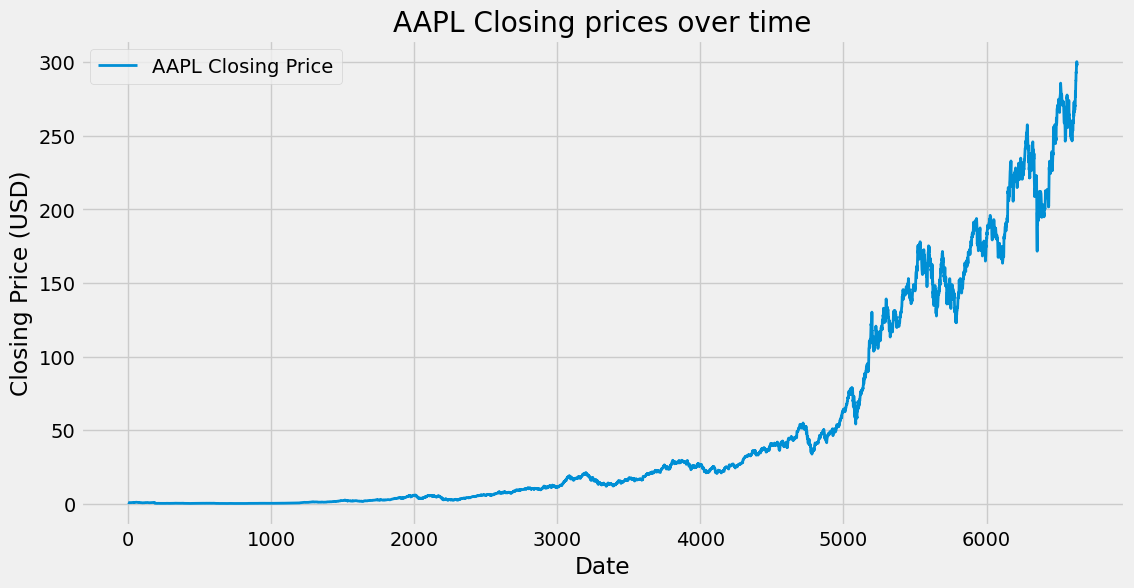

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 2)
plt.title(f'{stock} Closing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

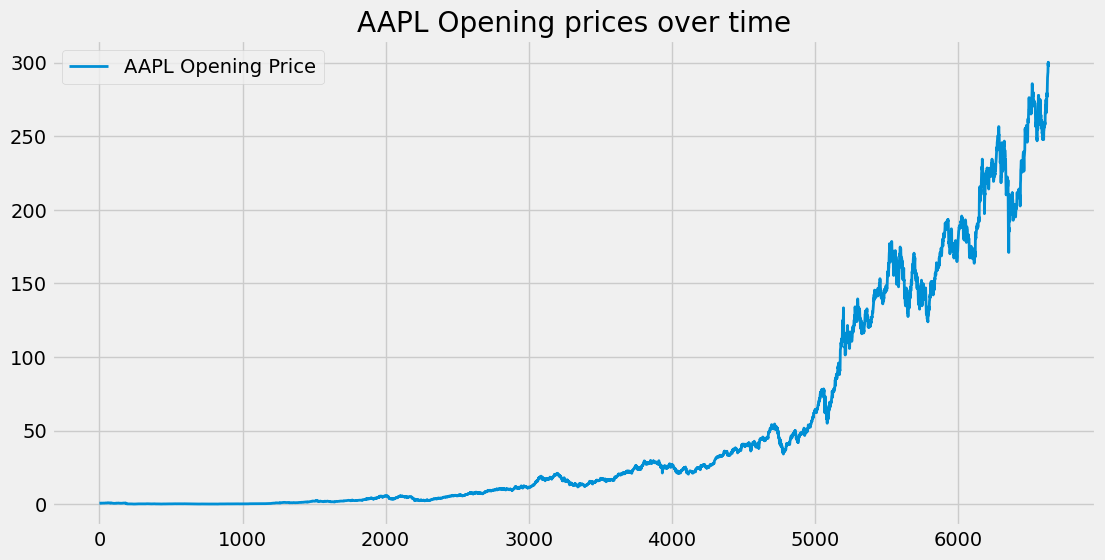

In [59]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 2)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

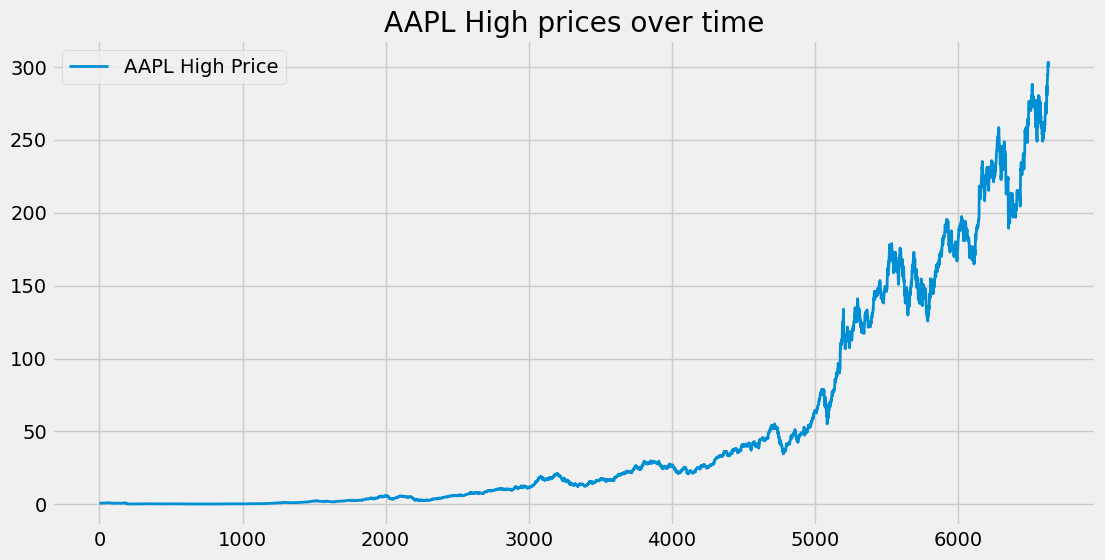

In [60]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 2)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth = 2)
plt.title(f'{stock} Low prices over time')
plt.legend()
plt.show()

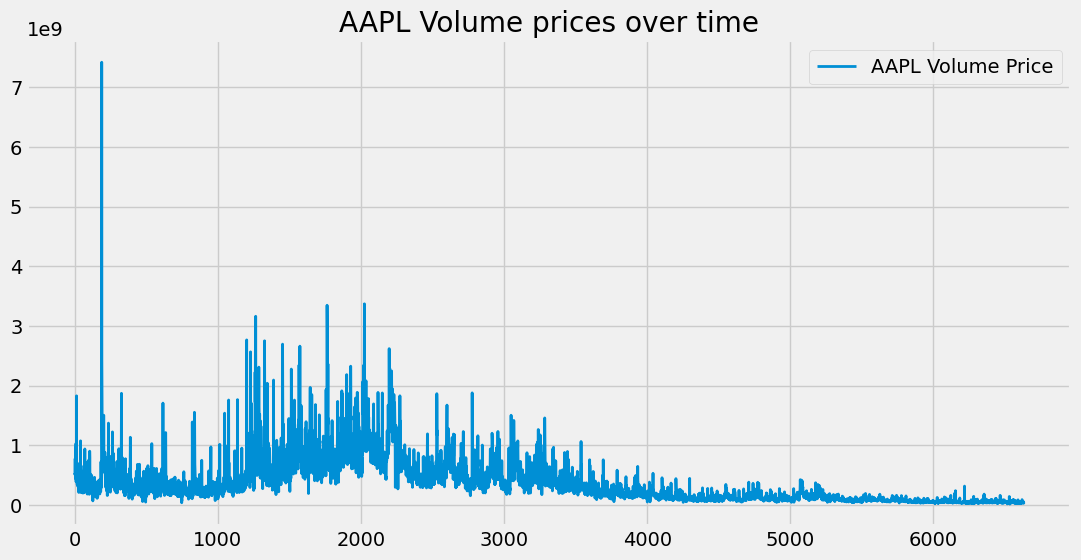

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume Price', linewidth = 2)
plt.title(f'{stock} Volume prices over time')
plt.legend()
plt.show()

In [63]:
ma100 = df.Close.rolling(100).mean()
# .Close: Selects only the column containing the final daily closing prices
# .rolling(100): Groups the data into a sliding window of 100 consecutive days.
# .mean(): Calculates the mathematical average of the 100 days inside that window.

In [64]:
ma200 = df.Close.rolling(200).mean()


In [65]:
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
6629,264.528319
6630,264.793566
6631,265.064241
6632,265.337966


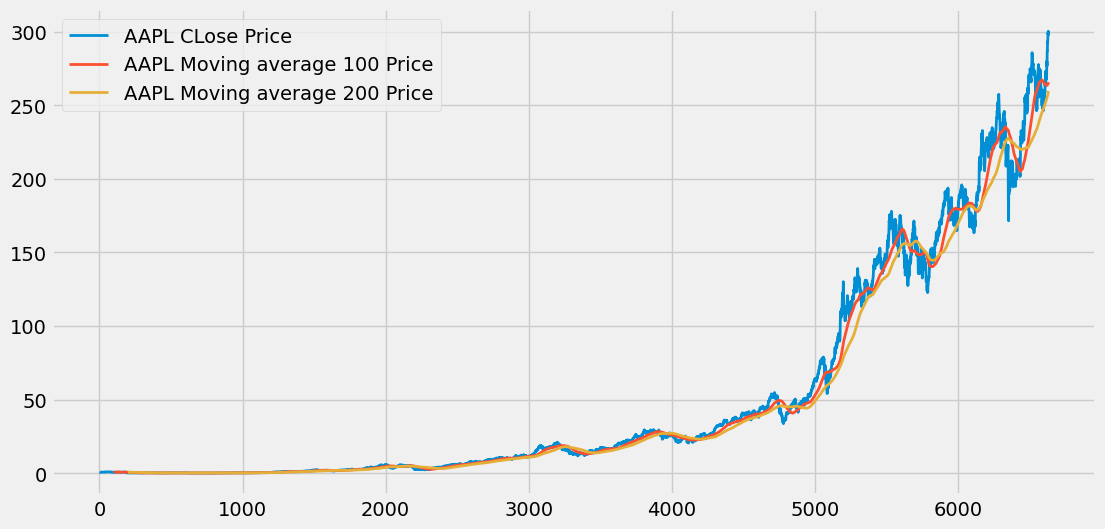

In [66]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} CLose Price', linewidth = 2)
plt.plot(ma100, label = f'{stock} Moving average 100 Price', linewidth = 2)
plt.plot(ma200, label = f'{stock} Moving average 200 Price', linewidth = 2)
plt.legend()
plt.show()

In [67]:
ema100 = df.Close.ewm(span=100,adjust=False).mean()
ema200 = df.Close.ewm(span=200,adjust=False).mean()

# ewm(Exponential Weighted Moving) : Exponential moving average  


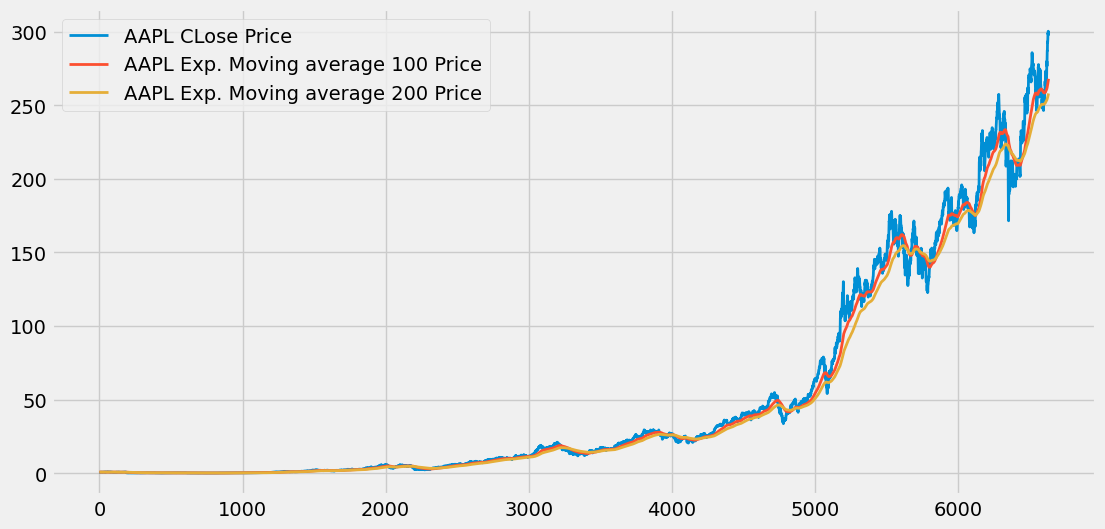

In [68]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} CLose Price', linewidth = 2)
plt.plot(ema100, label = f'{stock} Exp. Moving average 100 Price', linewidth = 2)
plt.plot(ema200, label = f'{stock} Exp. Moving average 200 Price', linewidth = 2)
plt.legend()
plt.show()

In [69]:
# RNN: Only remembers what happened in the last few days. It cannot connect a market crash from three months ago to today's market behavior.
# LSTM: Uses a "Cell State" (an internal memory conveyor belt) to preserve crucial historical data across hundreds of days without losing structural signal strength

In [70]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Open'][int(len(df)*0.70):int(len(df))])

In [71]:
data_training.shape

(4643, 1)

In [72]:
data_testing.shape


(1991, 1)

In [73]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler(feature_range = (0,1))

In [74]:
data_training_array = scalar.fit_transform(data_training)

In [75]:
data_training_array

array([[0.01409297],
       [0.01254097],
       [0.01278763],
       ...,
       [0.98301774],
       [0.98353586],
       [0.97338786]], shape=(4643, 1))

In [76]:
x_train = []
y_train = []

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train , y_train = np.array(x_train),np.array(y_train)

In [77]:
x_train.shape

(4543, 100, 1)

In [78]:
# Model Building
# Keras is a high-level, open-source Python library used to build, train, and deploy artificial neural networks and deep learning models

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

LSTM Input -> 3D Array (batch_size , time_stamps , seq_len)
LSTM 2D or 3D
2D -> (batch_sizm units)
3D -> (batch_size , time_stamps , units)

In [79]:
model = Sequential()

model.add(LSTM(units = 50, activation='relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))
model.add(LSTM(units = 80, activation='relu', return_sequences = True))
model.add(Dropout(0.4))
model.add(LSTM(units = 120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/home/prakharj/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [80]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer = 'adam',loss='mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - loss: 0.0134
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - loss: 0.0042
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 26s 185ms/step - loss: 0.0035
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 0.0035
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 0.0032
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 0.0032
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 0.0033
Epoch 8/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - loss: 0.0027
Epoch 9/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - loss: 0.0029
Epoch 10/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 0.0029
Epoch 11/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 0.0026
Epoch 12/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 0.0028
Epoch 13/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 0.0027
Epoch 14/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - loss: 0.0025
Epoch 15/50
142

In [85]:
past_100_days = data_training.tail(100)

In [90]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [91]:
input_data = scalar.fit_transform(final_df)

In [92]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [93]:
x_test.shape

(1991, 100, 1)

In [94]:
y_predicted = model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step


In [95]:
y_predicted.shape

(1991, 1)

In [97]:
scalar.scale_

array([0.00375829])

In [98]:
scaler_factor = 1/0.0035166
y_predicted = y_predicted*scaler_factor
y_test = y_test*scaler_factor


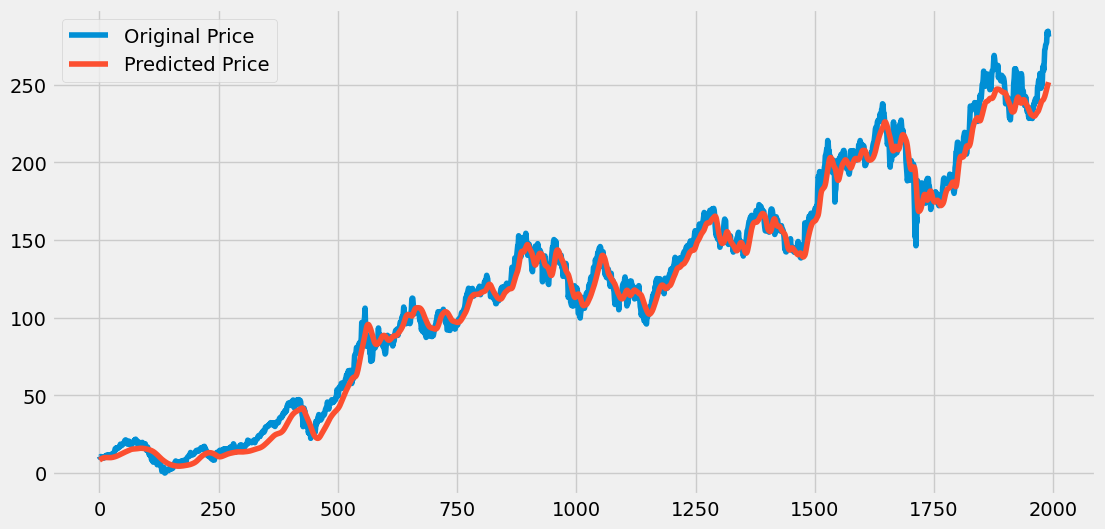

In [100]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Original Price')
plt.plot(y_predicted, label = 'Predicted Price')
plt.legend()
plt.show()

In [101]:
model.save('stock_dl_model.h5')